<a href="https://colab.research.google.com/github/Elkin535/A---HEURISTICA---Teoria-juego/blob/main/La_Guerra_de_Precios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

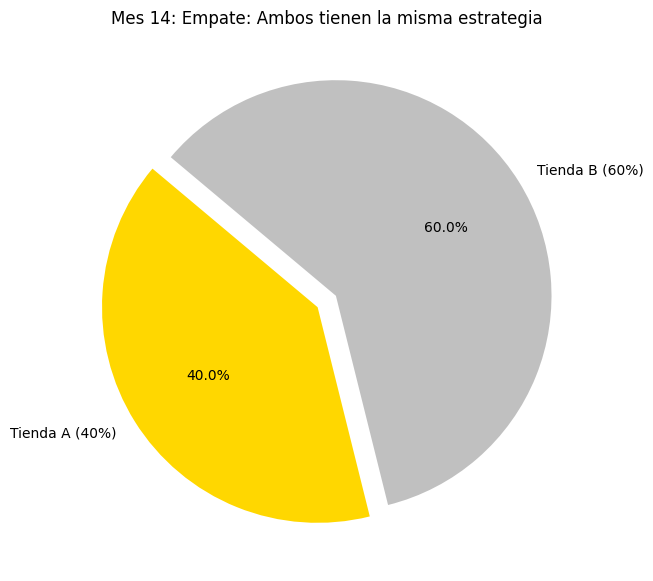

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import time

def price_war_viz():
    # Mercado inicial: cada tienda tiene 50% de los clientes
    share_a = 50
    share_b = 50

    # Creamos la ventana de dibujo
    fig, ax = plt.subplots(figsize=(7, 7))

    for r in range(15):
        # --- TEORÍA DE JUEGOS EN ACCIÓN ---
        # La Tienda A decide al azar si bajar precios ("Low") o mantenerlos ("High")
        action_a = np.random.choice(["High", "Low"])

        # La Tienda B es agresiva: después del mes 5, siempre baja los precios
        action_b = "Low" if r > 5 else "High"

        # Reglas del juego:
        # 1. Si A baja precios y B no, A le roba 10% de clientes a B
        if action_a == "Low" and action_b == "High":
            share_a = min(100, share_a + 10)
            share_b = max(0, share_b - 10)
            status = "¡Tienda A baja precios y gana clientes!"

        # 2. Si B baja precios y A no, B le roba 10% a A
        elif action_a == "High" and action_b == "Low":
            share_a = max(0, share_a - 10)
            share_b = min(100, share_b + 10)
            status = "¡Tienda B baja precios y roba mercado!"

        # 3. Si ambos bajan precios o ambos los mantienen, nadie gana clientes nuevos
        else:
            status = "Empate: Ambos tienen la misma estrategia"

        # --- DIBUJAR EL RESULTADO ---
        ax.clear()
        # Creamos el gráfico de pastel
        ax.pie([share_a, share_b],
               labels=[f'Tienda A ({share_a}%)', f'Tienda B ({share_b}%)'],
               autopct='%1.1f%%',
               colors=['gold', 'silver'],
               startangle=140,
               explode=(0.05, 0.05)) # Separa un poco las tajadas

        ax.set_title(f"Mes {r}: {status}", fontsize=12)

        # Refrescar en Colab
        ipythondisplay.clear_output(wait=True)
        ipythondisplay.display(fig)
        time.sleep(0.6) # Pausa para que podamos ver el cambio

    plt.close()

# Ejecutar la simulación
price_war_viz()